# 04 - Evaluación seria del clasificador LLM

Evaluación con Groq real (`llama-3.3-70b-versatile`) sobre replies etiquetados y matriz de confusión.

In [1]:
from pathlib import Path
import json
import os
import sys
import time

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Cargar .env local sin imprimir secretos.
env_path = ROOT / '.env'
if env_path.exists():
    for line in env_path.read_text(encoding='utf-8').splitlines():
        if not line or line.strip().startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        os.environ.setdefault(key.strip(), value.strip())

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.qualification.llm_qualifier import classify_reply

assert os.environ.get('GROQ_API_KEY'), 'Falta GROQ_API_KEY en entorno o .env'
labels = ['agendar', 'nurture', 'descartar']
merchant_context = {
    'brand_id': 'Brand_0145',
    'category': 'Hogar',
    'gmv_cop_millions_12m': 4908,
    'gmv_90d_to_12m_ratio': 3.25,
    'final_score': 89.2,
}
print('Setup OK: Groq key cargada sin mostrar valor')

Setup OK: Groq key cargada sin mostrar valor


## Dataset etiquetado

In [2]:
eval_cases = [
    {'id': 'directo_agendar', 'reply': 'Sí me interesa, ¿podemos agendar una llamada esta semana con mi socio?', 'expected': 'agendar', 'variant': 'interés claro'},
    {'id': 'demo_cfo', 'reply': 'Suena bien. Mándame agenda para verlo con el CFO.', 'expected': 'agendar', 'variant': 'decision maker mixto'},
    {'id': 'spanglish_interest', 'reply': 'Looks interesting, let us schedule a quick call next week.', 'expected': 'agendar', 'variant': 'spanglish'},
    {'id': 'reply_corto', 'reply': 'Sí, agendemos.', 'expected': 'agendar', 'variant': 'reply corto 3 palabras'},
    {'id': 'pregunta_integracion', 'reply': 'Me interesa, pero antes necesito entender cuánto esfuerzo de integración técnica requiere.', 'expected': 'nurture', 'variant': 'interés con objeción'},
    {'id': 'precio_alto', 'reply': 'La comisión me preocupa; vendiendo directo hoy me sale más barato.', 'expected': 'nurture', 'variant': 'precio'},
    {'id': 'tiempo_no_ahora', 'reply': 'Puede ser útil, pero ahora estamos cerrando inventario. Recuérdame en un mes.', 'expected': 'nurture', 'variant': 'timing'},
    {'id': 'dos_intenciones', 'reply': 'Nos interesa explorar, aunque si la comisión es alta preferimos esperar.', 'expected': 'nurture', 'variant': 'dos intenciones mezcladas'},
    {'id': 'sarcasmo', 'reply': 'Claro, porque justo nos sobra tiempo para otro marketplace... mejor mándame info y lo miro después.', 'expected': 'nurture', 'variant': 'sarcasmo suave'},
    {'id': 'ambiguo', 'reply': 'Podría ser. ¿Tienes más información?', 'expected': 'nurture', 'variant': 'ambiguo'},
    {'id': 'competidor', 'reply': 'Ya trabajamos con otro marketplace y por ahora no queremos duplicar operación.', 'expected': 'nurture', 'variant': 'competidor'},
    {'id': 'rechazo_claro', 'reply': 'No nos interesa Marketplace. Gracias.', 'expected': 'descartar', 'variant': 'rechazo claro'},
    {'id': 'opt_out', 'reply': 'Por favor no me vuelvan a escribir a este correo.', 'expected': 'descartar', 'variant': 'opt-out'},
    {'id': 'fuera_de_rol', 'reply': 'Yo no veo estos temas, no soy la persona indicada.', 'expected': 'descartar', 'variant': 'no decision maker sin derivación'},
    {'id': 'spam', 'reply': 'unsubscribe', 'expected': 'descartar', 'variant': 'unsubscribe'},
    {'id': 'corto_no', 'reply': 'No gracias.', 'expected': 'descartar', 'variant': 'reply corto'},
]
eval_df = pd.DataFrame(eval_cases)
eval_df

,id,reply,expected,variant
0,directo_agendar,"Sí me interesa, ¿podemos agendar una llamada e...",agendar,interés claro
1,demo_cfo,Suena bien. Mándame agenda para verlo con el CFO.,agendar,decision maker mixto
2,spanglish_interest,"Looks interesting, let us schedule a quick cal...",agendar,spanglish
3,reply_corto,"Sí, agendemos.",agendar,reply corto 3 palabras
4,pregunta_integracion,"Me interesa, pero antes necesito entender cuán...",nurture,interés con objeción
5,precio_alto,La comisión me preocupa; vendiendo directo hoy...,nurture,precio
6,tiempo_no_ahora,"Puede ser útil, pero ahora estamos cerrando in...",nurture,timing
7,dos_intenciones,"Nos interesa explorar, aunque si la comisión e...",nurture,dos intenciones mezcladas
8,sarcasmo,"Claro, porque justo nos sobra tiempo para otro...",nurture,sarcasmo suave
9,ambiguo,Podría ser. ¿Tienes más información?,nurture,ambiguo


## Funciones de evaluación

In [3]:
def run_eval(cases):
    rows = []
    for case in cases:
        q = classify_reply(case['reply'], merchant_context)
        rows.append({
            **case,
            'predicted': q.suggested_action,
            'intent_score': q.intent_score,
            'reasoning': q.reasoning,
            'correct': q.suggested_action == case['expected'],
        })
        time.sleep(0.25)
    return pd.DataFrame(rows)


def confusion_matrix_df(results):
    matrix = pd.DataFrame(0, index=labels, columns=labels)
    for _, row in results.iterrows():
        matrix.loc[row['expected'], row['predicted']] += 1
    return matrix


def plot_confusion(matrix, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matrix.values, cmap='Blues')
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_xlabel('Predicción LLM')
    ax.set_ylabel('Etiqueta esperada')
    ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, matrix.iloc[i, j], ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## Evaluación inicial con Groq real

In [4]:
initial_results = run_eval(eval_cases)
initial_accuracy = initial_results['correct'].mean()
initial_matrix = confusion_matrix_df(initial_results)
print(f'Accuracy inicial: {initial_accuracy:.1%}')
initial_results[['id','variant','expected','predicted','intent_score','correct','reasoning']]

Accuracy inicial: 93.8%


,id,variant,expected,predicted,intent_score,correct,reasoning
0,directo_agendar,interés claro,agendar,agendar,90,True,El merchant muestra interés y solicita agendar...
1,demo_cfo,decision maker mixto,agendar,agendar,90,True,El merchant muestra interés y solicita reunión...
2,spanglish_interest,spanglish,agendar,agendar,90,True,El merchant muestra interés y propone agendar ...
3,reply_corto,reply corto 3 palabras,agendar,agendar,100,True,El merchant muestra interés claro y propone ag...
4,pregunta_integracion,interés con objeción,nurture,nurture,60,True,El merchant muestra interés pero tiene objecio...
5,precio_alto,precio,nurture,nurture,50,True,"El merchant muestra interés parcial, pero se m..."
6,tiempo_no_ahora,timing,nurture,nurture,60,True,El merchant muestra interés pero no es el mome...
7,dos_intenciones,dos intenciones mezcladas,nurture,nurture,60,True,El merchant muestra interés pero objeta el precio
8,sarcasmo,sarcasmo suave,nurture,nurture,40,True,El merchant muestra interés parcial pero objet...
9,ambiguo,ambiguo,nurture,nurture,60,True,El merchant muestra interés parcial y solicita...


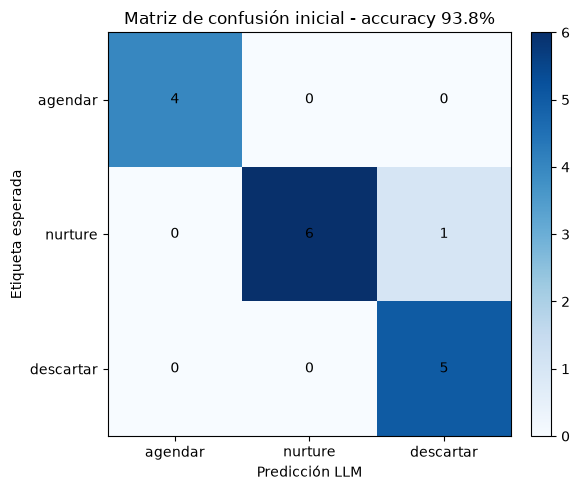

,agendar,nurture,descartar
agendar,4,0,0
nurture,0,6,1
descartar,0,0,5


In [5]:
plot_confusion(initial_matrix, f'Matriz de confusión inicial - accuracy {initial_accuracy:.1%}')
initial_matrix

## Ajuste condicional del prompt si accuracy < 80%

In [6]:
prompt_path = ROOT / 'src' / 'qualification' / 'qualifier_prompt.md'
FEW_SHOT_BLOCK = '''

Ejemplos adicionales para casos ambiguos:
- Reply: "Nos interesa explorar, aunque si la comisión es alta preferimos esperar."
  JSON esperado: {"intent_score": 55, "is_decision_maker": true, "objection_type": "precio", "suggested_action": "nurture", "reasoning": "Hay interés, pero una objeción de precio bloquea agendar todavía."}
- Reply: "Claro, porque justo nos sobra tiempo para otro marketplace... mejor mándame info y lo miro después."
  JSON esperado: {"intent_score": 45, "is_decision_maker": false, "objection_type": "tiempo", "suggested_action": "nurture", "reasoning": "Sarcasmo con permiso de enviar información; no es opt-out."}
- Reply: "Yo no veo estos temas, no soy la persona indicada."
  JSON esperado: {"intent_score": 15, "is_decision_maker": false, "objection_type": null, "suggested_action": "descartar", "reasoning": "No hay interés ni derivación a un responsable."}
'''

prompt_before = prompt_path.read_text(encoding='utf-8')
prompt_was_adjusted = False
if initial_accuracy < 0.80 and 'Ejemplos adicionales para casos ambiguos:' not in prompt_before:
    prompt_path.write_text(prompt_before.rstrip() + FEW_SHOT_BLOCK + '\n', encoding='utf-8')
    prompt_was_adjusted = True
    print('Accuracy < 80%; prompt ajustado con few-shot y se reevalúa.')
else:
    print('No se ajusta prompt: accuracy >= 80% o few-shot ya presente.')
print({'prompt_was_adjusted': prompt_was_adjusted})

No se ajusta prompt: accuracy >= 80% o few-shot ya presente.
{'prompt_was_adjusted': False}


## Evaluación final

In [7]:
if prompt_was_adjusted:
    final_results = run_eval(eval_cases)
else:
    final_results = initial_results.copy()
final_accuracy = final_results['correct'].mean()
final_matrix = confusion_matrix_df(final_results)
print(f'Accuracy final: {final_accuracy:.1%}')
final_results[['id','variant','expected','predicted','intent_score','correct','reasoning']]

Accuracy final: 93.8%


,id,variant,expected,predicted,intent_score,correct,reasoning
0,directo_agendar,interés claro,agendar,agendar,90,True,El merchant muestra interés y solicita agendar...
1,demo_cfo,decision maker mixto,agendar,agendar,90,True,El merchant muestra interés y solicita reunión...
2,spanglish_interest,spanglish,agendar,agendar,90,True,El merchant muestra interés y propone agendar ...
3,reply_corto,reply corto 3 palabras,agendar,agendar,100,True,El merchant muestra interés claro y propone ag...
4,pregunta_integracion,interés con objeción,nurture,nurture,60,True,El merchant muestra interés pero tiene objecio...
5,precio_alto,precio,nurture,nurture,50,True,"El merchant muestra interés parcial, pero se m..."
6,tiempo_no_ahora,timing,nurture,nurture,60,True,El merchant muestra interés pero no es el mome...
7,dos_intenciones,dos intenciones mezcladas,nurture,nurture,60,True,El merchant muestra interés pero objeta el precio
8,sarcasmo,sarcasmo suave,nurture,nurture,40,True,El merchant muestra interés parcial pero objet...
9,ambiguo,ambiguo,nurture,nurture,60,True,El merchant muestra interés parcial y solicita...


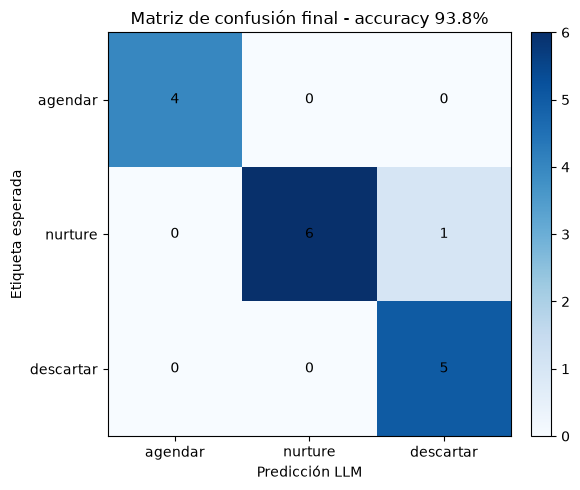

,agendar,nurture,descartar
agendar,4,0,0
nurture,0,6,1
descartar,0,0,5


In [8]:
plot_confusion(final_matrix, f'Matriz de confusión final - accuracy {final_accuracy:.1%}')
final_matrix

## Análisis de errores

In [9]:
errors = final_results[~final_results['correct']].copy()
if errors.empty:
    display(Markdown('**No hubo errores en la evaluación final.**'))
else:
    bullets = []
    for _, row in errors.iterrows():
        bullets.append(
            f"- **{row['id']}**: esperado `{row['expected']}`, predicho `{row['predicted']}`. "
            f"Probable causa: el texto mezcla señales o el LLM ponderó más `{row['reasoning']}`."
        )
    display(Markdown('\n'.join(bullets)))

- **competidor**: esperado `nurture`, predicho `descartar`. Probable causa: el texto mezcla señales o el LLM ponderó más `El merchant ya trabaja con otro marketplace y no desea duplicar operaciones`.

In [10]:
assert final_accuracy >= 0.80, f'Accuracy final menor a 80%: {final_accuracy:.1%}'
print('Evaluación LLM PASS')

Evaluación LLM PASS
